# Proyecto Integrador IV
> E-Commerce Data Pipeline

En este notebook, primero ejecutaremos todos los componentes de nuestro pipeline ELT y luego realizaremos visualizaciones con la información resultante


In [1]:
# Importing the necessary libraries
from pandas import DataFrame
from sqlalchemy import create_engine
from typing import Dict
from pathlib import Path

from src.transform import QueryEnum
from src import config
from src.transform import run_queries
from src.extract import extract
from src.load import load
from src.plots import (
    plot_freight_value_weight_relationship,
    plot_global_amount_order_status,
    plot_real_vs_predicted_delivered_time,
    plot_revenue_by_month_year,
    plot_revenue_per_state,
    plot_top_10_least_revenue_categories,
    plot_top_10_revenue_categories,
    plot_top_10_revenue_categories_ammount,
    plot_delivery_date_difference,
    plot_order_amount_per_day_with_holidays,
)

In [2]:
# Create the database sql file
Path(config.SQLITE_BD_ABSOLUTE_PATH).touch()

# Create the database connection
ENGINE = create_engine(rf"sqlite:///{config.SQLITE_BD_ABSOLUTE_PATH}", echo=False)

### 1. Extract

Aquí estarás extrayendo la información de las fuentes.

In [3]:
csv_folder = config.DATASET_ROOT_PATH
public_holidays_url = config.PUBLIC_HOLIDAYS_URL

# 1. Get the mapping of the csv files to the table names.
csv_table_mapping = config.get_csv_to_table_mapping()

# 2. Extract the data from the csv files, holidays and load them into the dataframes.
csv_dataframes = extract(csv_folder, csv_table_mapping, public_holidays_url)

### 2. Load

Usando los diferentes conjuntos de datos proporcionados, almacenarás todo en nuestro Data Warehouse.

In [4]:
load(data_frames=csv_dataframes, database=ENGINE)

Tabla 'olist_customers' eliminada correctamente.
Tabla 'olist_geolocation' eliminada correctamente.
Tabla 'olist_order_items' eliminada correctamente.
Tabla 'olist_order_payments' eliminada correctamente.
Tabla 'olist_order_reviews' eliminada correctamente.
Tabla 'olist_orders' eliminada correctamente.
Tabla 'olist_products' eliminada correctamente.
Tabla 'olist_sellers' eliminada correctamente.
Tabla 'product_category_name_translation' eliminada correctamente.
Tabla 'public_holidays' eliminada correctamente.
Tabla 'olist_customers' cargada exitosamente.
Tabla 'olist_geolocation' cargada exitosamente.
Tabla 'olist_order_items' cargada exitosamente.
Tabla 'olist_order_payments' cargada exitosamente.
Tabla 'olist_order_reviews' cargada exitosamente.
Tabla 'olist_orders' cargada exitosamente.
Tabla 'olist_products' cargada exitosamente.
Tabla 'olist_sellers' cargada exitosamente.
Tabla 'product_category_name_translation' cargada exitosamente.
Tabla 'public_holidays' cargada exitosamente.


### 3. Transform

Aquí transformarás las diferentes consultas en tablas. Hay dos secciones: una con las consultas relacionadas con los ingresos y otra con las consultas relacionadas con las entregas.

##### 3.1 Queries sobre ingresos

In [5]:
query_results: Dict[str, DataFrame] = run_queries(database=ENGINE)

In [6]:
# Transforming the revenue_by_month_year query to a table
revenue_by_month_year = query_results[QueryEnum.REVENUE_BY_MONTH_YEAR.value]
revenue_by_month_year

,month_no,month,Year2016,Year2017,Year2018
0,01,Jan,0.00,127545.67,1078606.86
1,02,Feb,0.00,271298.65,966510.88
2,03,Mar,0.00,414369.39,1120678.00
3,04,Apr,0.00,390952.18,1132933.95
4,05,May,0.00,567066.73,1128836.69
5,06,Jun,0.00,490225.60,1012090.68
6,07,Jul,0.00,566403.93,1027903.86
7,08,Aug,0.00,646000.61,985414.28
8,09,Sep,0.00,701169.99,0.00
9,10,Oct,46566.71,751140.27,0.00


In [7]:
# Transforming the top_10_revenue_categories query to a table
top_10_revenue_categories = query_results[QueryEnum.TOP_10_REVENUE_CATEGORIES.value]
top_10_revenue_categories

,Category,Num_order,Revenue
0,bed_bath_table,9272,1692714.28
1,health_beauty,8646,1620684.04
2,computers_accessories,6529,1549252.47
3,furniture_decor,6307,1394466.93
4,watches_gifts,5493,1387046.31
5,sports_leisure,7529,1349252.93
6,housewares,5743,1069787.97
7,auto,3809,833610.84
8,garden_tools,3448,810614.93
9,cool_stuff,3559,744649.32


In [8]:
# Transforming the top_10_least_revenue_categories query to a table
top_10_least_revenue_categories = query_results[
    QueryEnum.TOP_10_LEAST_REVENUE_CATEGORIES.value
]
top_10_least_revenue_categories

,Category,Num_order,Revenue
0,security_and_services,2,324.51
1,fashion_childrens_clothes,7,718.98
2,cds_dvds_musicals,12,1199.43
3,home_comfort_2,24,1710.54
4,flowers,29,2213.01
5,arts_and_craftmanship,23,2326.17
6,la_cuisine,13,2913.53
7,fashion_sport,26,3605.83
8,diapers_and_hygiene,25,4126.17
9,fashio_female_clothing,36,4902.67


In [9]:
# Transforming the revenue_per_state query to a table
revenue_per_state = query_results[QueryEnum.REVENUE_PER_STATE.value]
revenue_per_state

,customer_state,Revenue
0,SP,5769081.27
1,RJ,2055690.45
2,MG,1819277.61
3,RS,861608.40
4,PR,781919.55
5,SC,595208.40
6,BA,591270.60
7,DF,346146.17
8,GO,334294.22
9,ES,317682.65


##### 3.2 Queries sobre entregas

In [10]:
# Transforming the delivery_date_difference query to a table
delivery_date_difference = query_results[QueryEnum.DELIVERY_DATE_DIFFERECE.value]
delivery_date_difference

,State,Delivery_Difference
0,AL,8
1,MA,9
2,BA,10
3,CE,10
4,ES,10
5,SE,10
6,MS,11
7,PI,11
8,RJ,11
9,SC,11


In [11]:
# Transforming the real vs predicted delivered time query to a table per month and year
real_vs_estimated_delivered_time = query_results[
    QueryEnum.REAL_VS_ESTIMATED_DELIVERED_TIME.value
]
real_vs_estimated_delivered_time

,month_no,month,Year2016_real_time,Year2017_real_time,Year2018_real_time,Year2016_estimated_time,Year2017_estimated_time,Year2018_estimated_time
0,01,Jan,NaN,12.647044,14.080563,NaN,39.508831,26.302555
1,02,Feb,NaN,13.168825,16.945138,NaN,31.848929,24.528996
2,03,Mar,NaN,12.951184,16.301410,NaN,24.732386,22.033067
3,04,Apr,NaN,14.917913,11.499241,NaN,27.349810,23.679546
4,05,May,NaN,11.322363,11.419029,NaN,24.284784,22.891488
5,06,Jun,NaN,12.011573,9.239216,NaN,24.021864,27.772740
6,07,Jul,NaN,11.592732,8.958636,NaN,23.317316,19.690127
7,08,Aug,NaN,11.147125,7.732780,NaN,23.480603,15.186330
8,09,Sep,54.813194,11.851007,NaN,18.488449,22.437366,NaN
9,10,Oct,19.600559,11.856700,NaN,55.676632,23.019536,NaN


In [12]:
# Transforming the global ammount of order status query to a table
global_ammount_order_status = query_results[QueryEnum.GLOBAL_AMMOUNT_ORDER_STATUS.value]
global_ammount_order_status

,order_status,Ammount
0,approved,2
1,canceled,625
2,created,5
3,delivered,96478
4,invoiced,314
5,processing,301
6,shipped,1107
7,unavailable,609


In [13]:
orders_per_day_and_holidays = query_results[
    QueryEnum.ORDERS_PER_DAY_AND_HOLIDAYS_2017.value
]
orders_per_day_and_holidays

,order_count,date,holiday
0,32,2017-01-05,False
1,4,2017-01-06,False
2,4,2017-01-07,False
3,6,2017-01-08,False
4,5,2017-01-09,False
...,...,...,...
356,167,2017-12-27,False
357,146,2017-12-28,False
358,135,2017-12-29,False
359,97,2017-12-30,False


In [14]:
freight_value_weight_relationship = query_results[
    QueryEnum.GET_FREIGHT_VALUE_WEIGHT_RELATIONSHIP.value
]

### 4. Graficas de las tablas resultantes

Ahora, crearemos gráficos a partir de las diferentes consultas.

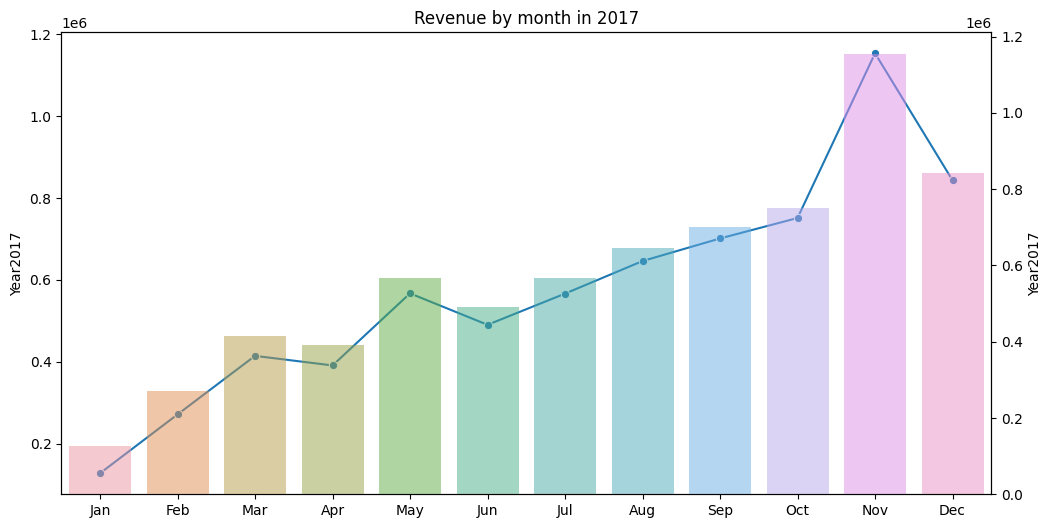

In [15]:
plot_revenue_by_month_year(revenue_by_month_year, 2017)

In [16]:
plot_top_10_revenue_categories(top_10_revenue_categories)

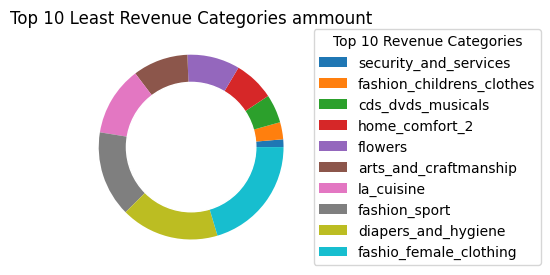

In [17]:
plot_top_10_least_revenue_categories(top_10_least_revenue_categories)

In [18]:
plot_revenue_per_state(revenue_per_state)

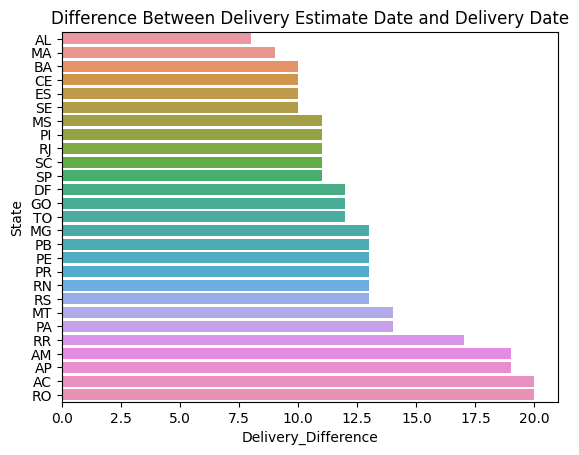

In [19]:
plot_delivery_date_difference(delivery_date_difference)

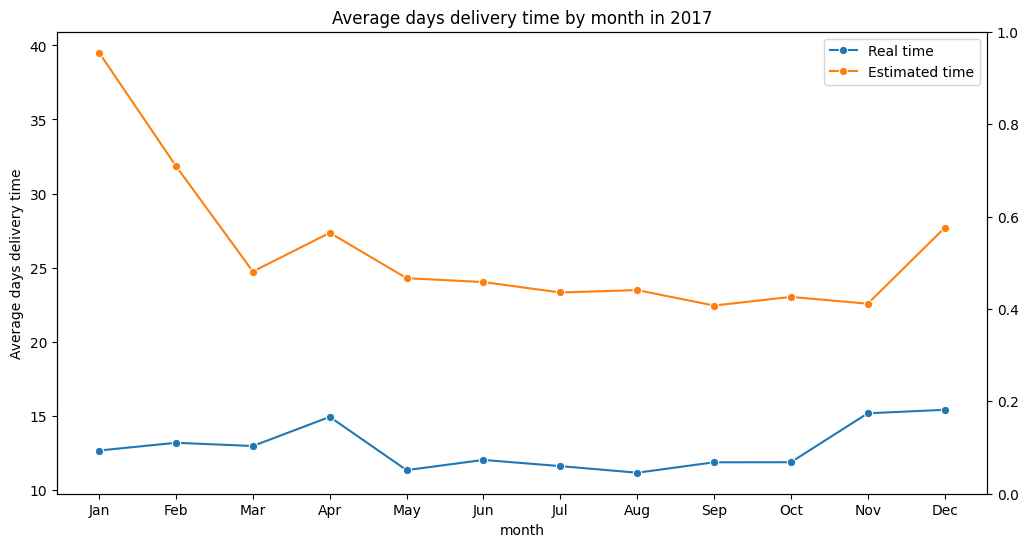

In [19]:
plot_real_vs_predicted_delivered_time(real_vs_estimated_delivered_time, year=2017)

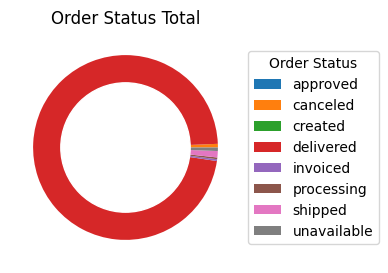

In [20]:
plot_global_amount_order_status(global_ammount_order_status)

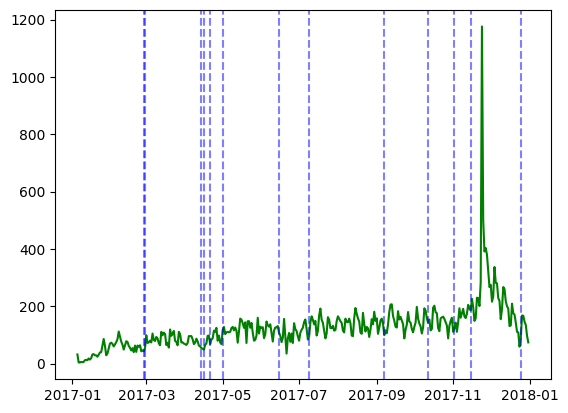

In [21]:
plot_order_amount_per_day_with_holidays(orders_per_day_and_holidays)

4.1 ¿Ves alguna relación entre los días festivos en Brasil durante 2017 y las compras de ese año?

Respuesta: A lo largo del año 2017, no se evidencia una relación directa entre los días festivos en Brasil y un aumento significativo en las compras. En la mayoría de los feriados, el volumen de pedidos se mantiene estable o incluso registra leves descensos, lo que podría atribuirse a una menor actividad comercial durante estos días, posiblemente por el cierre de establecimientos o cambios en los hábitos de consumo.

No obstante, se observa un incremento notable en las compras hacia finales de noviembre y principios de diciembre. Este pico coincide con eventos comerciales clave, como el Black Friday y el inicio de la temporada navideña. Esto sugiere que, mientras los feriados tradicionales no impulsan las ventas, los períodos de alta demanda estacional, como el Black Friday y la Navidad, tienen un impacto significativo en el comportamiento de los consumidores.



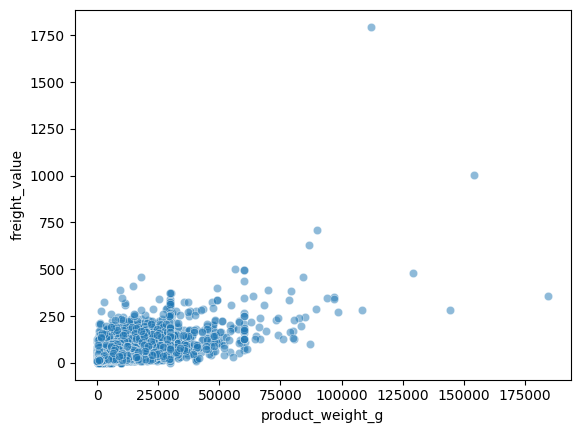

In [23]:
plot_freight_value_weight_relationship(freight_value_weight_relationship)

4.2 ¿Ves alguna correlación entre el valor del flete y el peso del producto?

Respuesta: El gráfico de dispersión muestra una correlación positiva entre el peso del producto (product_weight_g) y el valor del flete (freight_value). A medida que el peso del producto aumenta, el costo del flete tiende a subir, aunque no de manera completamente lineal ni uniforme.

Se observa una alta concentración de productos ligeros con fletes bajos, mientras que en pesos mayores la variabilidad del costo del flete es más amplia. Lo que sugiere que, además del peso hay otros factores logísticos como la distancia de envío, el tipo de transporte o tarifas adicionales que pueden influir en el valor del flete.
